In [1]:
import pandas as pd
from matplotlib import pyplot as plt

### Steps to Reproduce `SSSP-DEL`
1. Use `build-dataset.go` to ignore duplicate additions, making a single graph instead of a multi-graph
2. Run `lp-sssp-del -g data/hive-comments-merged-no-del.txt -d -c -w=5 -pt=1 -i=38806 -t=1 -dt=10`
3. `OnApplyTimeSeries` log `tse` stats

### Steps to Reproduce `SSSP`
1. Use the original dataset
2. Run `lp-sssp -g data/hive-comments.txt -d -c -pt=1 -i=38806 -t=1 -dt=10`
3. `OnApplyTimeSeries` log `tse` stats

commit id: `3712f9f7282cab581fb56e84318ebf40f7cf201c`
```bash
go run ./cmd/rand-graph/build-dataset.go data/hive-comments.txt  data/hive-comments-merged-w10-d0.txt 10; \
go run ./cmd/lp-sssp-del -g data/hive-comments-merged-w10-d0.txt -d -c -w=5 -pt=1 -i=38806 -t=1 -dt=10; \
go run ./cmd/lp-sssp -g data/hive-comments.txt -d -c -pt=1 -i=38806 -t=1 -dt=10
```

In [ ]:
tse_del_filename = "/Users/pjavanrood/Documents/NetSys/lollipop/cmd/lp-sssp-del/tse_stats_del_w_432000_dt_864000.csv"
tse_filename = "/Users/pjavanrood/Documents/NetSys/lollipop/cmd/lp-sssp/tse_stats_w_0_dt_864000.csv"
tse_oracle_filename = "/Users/pjavanrood/Documents/NetSys/lollipop/cmd/lp-sssp/tse_oracle_stats_w_432000_dt_864000.csv"

In [22]:
tse_del_df = pd.read_csv(tse_del_filename)
tse_df = pd.read_csv(tse_filename)
tse_oracle_df = pd.read_csv(tse_oracle_filename)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/pjavanrood/Documents/NetSys/lollipop/cmd/lp-sssp/tse_oracle_stats_w_432000_dt_864000.csv'

In [ ]:
tse_del_df['LatencySeconds'] = tse_del_df['Latency'] / (10 ** 9)
tse_del_df["CurrentRuntimeSeconds"] = tse_del_df["CurrentRuntime"] / (10 ** 9)
tse_del_df["EdgeCount%"] = tse_del_df["EdgeCount"] / max(tse_del_df["EdgeCount"])
tse_del_df["EdgeDelete%"] = tse_del_df["EdgeDelete"] / max(tse_del_df["EdgeDelete"])

tse_df['LatencySeconds'] = tse_df['Latency'] / (10 ** 9)
tse_df["CurrentRuntimeSeconds"] = tse_df["CurrentRuntime"] / (10 ** 9)
tse_df["EdgeCount%"] = tse_df["EdgeCount"] / max(tse_df["EdgeCount"])
tse_df["EdgeDelete%"] = tse_df["EdgeDelete"] / max(max(tse_df["EdgeDelete"]), 1)

tse_oracle_df["AbsoluteElapsedSeconds"] = tse_oracle_df["AbsoluteElapsed"] / (10 ** 9)
tse_oracle_df["ElapsedSeconds"] = tse_oracle_df["Elapsed"] / (10 ** 9)

In [20]:
tse_del_df.plot(x="AtEventIndex", y=["LatencySeconds", "EdgeCount%", "EdgeDelete%"])

KeyError: "None of [Index(['LatencySeconds', 'EdgeCount%', 'EdgeDelete%'], dtype='object')] are in the [columns]"

In [17]:
max(tse_del_df["EdgeCount"])

386420

In [18]:
max(tse_df["EdgeCount"])

80017108

<Axes: xlabel='AtEventIndex'>

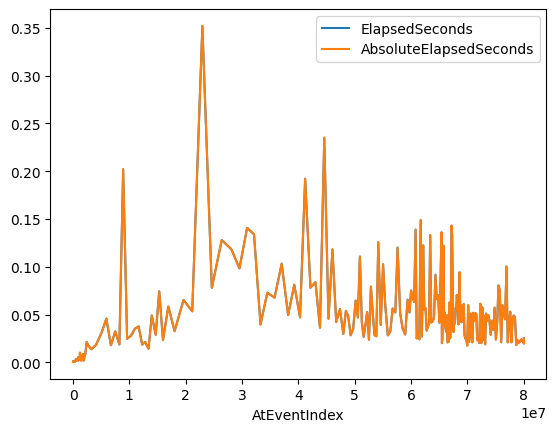

In [13]:
tse_oracle_df.plot(x="AtEventIndex", y=["ElapsedSeconds", "AbsoluteElapsedSeconds"])

In [14]:
print(f'Total Runtime for {tse_del_filename}: {max(tse_del_df["CurrentRuntime"]) / (10 ** 9)}')
tse_del_df.describe()

Total Runtime for /Users/pjavanrood/Documents/NetSys/lollipop/cmd/lp-sssp-del/tse_stats_del_w_432000_dt_864000.csv: 58.763901855


,Name,AtEventIndex,EdgeCount,EdgeDelete,Latency,AlgTimeSinceLast,CurrentRuntime,LatencySeconds,CurrentRuntimeSeconds,EdgeCount%,EdgeDelete%
count,237.0,2.370000e+02,237.000000,2.370000e+02,2.370000e+02,2.370000e+02,2.370000e+02,237.000000,237.000000,237.000000,237.000000
mean,0.0,1.447697e+07,47015.772152,1.442996e+07,1.942478e+08,5.295518e+06,3.494141e+10,0.194248,34.941411,0.121670,0.647818
std,0.0,8.212776e+06,72638.810361,8.232172e+06,3.169673e+08,1.065182e+07,2.109577e+10,0.316967,21.095769,0.187979,0.369575
min,0.0,0.000000e+00,1.000000,0.000000e+00,1.108600e+05,3.628800e+04,5.873505e+06,0.000111,0.005874,0.000003,0.000000
25%,0.0,5.942431e+06,10794.000000,5.846452e+06,3.872421e+07,1.026350e+06,1.131778e+10,0.038724,11.317776,0.027933,0.262470
50%,0.0,1.906760e+07,15562.000000,1.904396e+07,6.387196e+07,1.493007e+06,4.449248e+10,0.063872,44.492480,0.040272,0.854959
75%,0.0,2.052596e+07,34180.000000,2.051671e+07,1.510998e+08,3.612568e+06,5.156140e+10,0.151100,51.561395,0.088453,0.921076
max,0.0,2.229010e+07,386420.000000,2.227471e+07,1.853512e+09,1.074635e+08,5.876390e+10,1.853512,58.763902,1.000000,1.000000


<Axes: xlabel='CurrentRuntimeSeconds'>

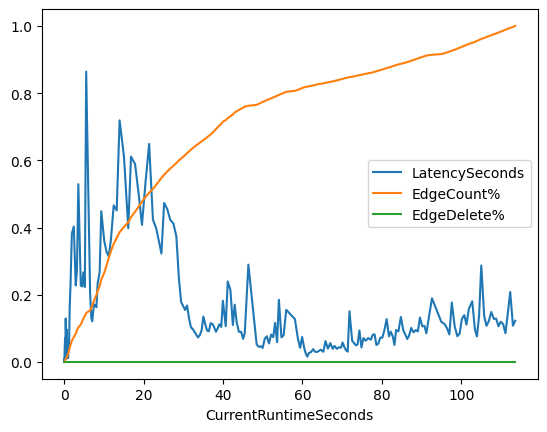

In [15]:
tse_df.plot(x="CurrentRuntimeSeconds", y=["LatencySeconds", "EdgeCount%", "EdgeDelete%"])

In [134]:
tse_df

,Name,AtEventIndex,EdgeCount,EdgeDelete,Latency,AlgTimeSinceLast,CurrentRuntime,LatencySeconds,CurrentRuntimeSeconds,EdgeCount%,EdgeDelete%
0,0,0,1.0,0.0,5246890.0,4335351.0,4368194.0,0.005247,0.004368,0.001957,0.0
1,389592,389840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,6,7.0,0.0,42784.0,40547.0,10758501.0,0.000043,0.010759,0.013699,0.0
3,372788,373001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,89,90.0,0.0,318691.0,68108.0,11301404.0,0.000319,0.011301,0.176125,0.0
5,330052,330260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,510,511.0,0.0,111723.0,121544.0,12178435.0,0.000112,0.012178,1.000000,0.0


In [108]:
print(f'Total Runtime for {tse_filename}: {max(tse_df["CurrentRuntime"]) / (10 ** 9)}')
tse_df.describe()

Total Runtime for /Users/pjavanrood/Documents/NetSys/lollipop/cmd/lp-sssp/tse_stats_w_0_dt_864000.csv: 97.977976872


,Name,AtEventIndex,EdgeCount,EdgeDelete,Latency,AlgTimeSinceLast,CurrentRuntime,LatencySeconds,CurrentRuntimeSeconds,EdgeCount%,EdgeDelete%
count,237.0,2.370000e+02,2.370000e+02,237.0,2.370000e+02,2.370000e+02,2.370000e+02,237.000000,237.000000,2.370000e+02,237.0
mean,0.0,4.603491e+07,4.603491e+07,0.0,9.742628e+07,1.717800e+07,3.902648e+10,0.097426,39.026476,5.753133e-01,0.0
std,0.0,2.841203e+07,2.841203e+07,0.0,1.093970e+08,2.639044e+07,3.182553e+10,0.109397,31.825531,3.550744e-01,0.0
min,0.0,0.000000e+00,1.000000e+00,0.0,2.882600e+04,2.335900e+04,2.303816e+06,0.000029,0.002304,1.249733e-08,0.0
25%,0.0,1.397855e+07,1.397856e+07,0.0,3.719322e+07,5.160206e+06,5.174187e+09,0.037193,5.174187,1.746946e-01,0.0
50%,0.0,5.895338e+07,5.895338e+07,0.0,6.527924e+07,8.540884e+06,3.638323e+10,0.065279,36.383229,7.367597e-01,0.0
75%,0.0,6.884232e+07,6.884232e+07,0.0,1.094186e+08,1.742795e+07,6.719041e+10,0.109419,67.190412,8.603450e-01,0.0
max,0.0,8.001711e+07,8.001711e+07,0.0,5.998268e+08,2.048053e+08,9.797798e+10,0.599827,97.977977,1.000000e+00,0.0
